In [75]:
import pandas as pd


df_raw = pd.read_csv("ClaimDenialInputMultiLabel.csv")

C:\Users\SreejaChiluveru\AppData\Local\Temp\ipykernel_20484\680313507.py:4: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("ClaimDenialInputMultiLabel.csv")


In [76]:
print(df_raw.shape)
print(df_raw.columns)
print(df_raw.head())

(1000000, 39)
Index(['Clinic', 'TPCLIID', 'LIATPCLIid', 'ServiceDt', 'Service', 'ClaimID',
       'AmountCharged', 'CPTCode', 'ClientID', 'ClaimBillDate', 'Payer',
       'Provider', 'BillingProviderNPI', 'ClaimFacilityNPI', 'AuthStatus',
       'eligStatus', 'DenialFlag', 'lastActDt', 'cliANSI1', 'cliANSI2',
       'target1', 'target2', 'target3', 'target4', 'TotalPaid', 'TotalAdj',
       'TotalVoid', 'CoPay', 'Deduc', 'CoIns', 'CltResp', 'Balance',
       'MultiFlag', 'SameDayCli', 'DaysBetServiceToBilling',
       'tpcliStrModifier', 'tpcliStrPOS', 'f21diag1', 'f11insdob'],
      dtype='object')
         Clinic      TPCLIID    LIATPCLIid   ServiceDt  \
0  CLN_13838227  TP_41935074   LTP_1870199  2025-06-22   
1  CLN_13838227  TP_44604858  LTP_82010373  2025-06-29   
2  CLN_13838227  TP_26594858           NaN  2025-07-06   
3  CLN_13838227  TP_95683641   LTP_2144057  2025-07-13   
4  CLN_13838227  TP_90042682  LTP_38875939  2025-07-20   

                      Service    ClaimID  Am

In [77]:
df=df_raw.copy()


In [78]:
print(df.isnull().sum())

Clinic                           0
TPCLIID                          0
LIATPCLIid                   73985
ServiceDt                        0
Service                          0
ClaimID                          0
AmountCharged                    0
CPTCode                          0
ClientID                         0
ClaimBillDate                    0
Payer                            0
Provider                        12
BillingProviderNPI               0
ClaimFacilityNPI                 0
AuthStatus                 1000000
eligStatus                  234760
DenialFlag                   73985
lastActDt                    73985
cliANSI1                    778408
cliANSI2                    980313
target1                     778410
target2                     965909
target3                     996126
target4                     999014
TotalPaid                        0
TotalAdj                         0
TotalVoid                        0
CoPay                            0
Deduc               

In [79]:
#Drop fully null column
df = df.drop(columns=["f11insdob"])


In [80]:

df = df.drop(columns=["AuthStatus"])

In [81]:
leakage_cols = [
    "TotalPaid",
    "TotalAdj",
    "TotalVoid",
    "Balance",
    "lastActDt",
    "cliANSI1",
    "cliANSI2"
]

df = df.drop(columns=leakage_cols, errors="ignore")

In [82]:
id_cols = [
    "TPCLIID",
    "LIATPCLIid",
    "ClaimID",
    "ClientID"
]

df = df.drop(columns=id_cols, errors="ignore")

In [83]:
X = df.drop(columns=[
    "DenialFlag",
    "MultiFlag",
    "target1","target2","target3","target4"
])

y = df["DenialFlag"]

In [84]:
other_targets = [
    "MultiFlag",
    "target1","target2","target3","target4"
]

In [85]:
df = df.drop(columns=other_targets, errors="ignore")

In [86]:
print(df.columns)

Index(['Clinic', 'ServiceDt', 'Service', 'AmountCharged', 'CPTCode',
       'ClaimBillDate', 'Payer', 'Provider', 'BillingProviderNPI',
       'ClaimFacilityNPI', 'eligStatus', 'DenialFlag', 'CoPay', 'Deduc',
       'CoIns', 'CltResp', 'SameDayCli', 'DaysBetServiceToBilling',
       'tpcliStrModifier', 'tpcliStrPOS', 'f21diag1'],
      dtype='object')


In [87]:
print(X.columns)

Index(['Clinic', 'ServiceDt', 'Service', 'AmountCharged', 'CPTCode',
       'ClaimBillDate', 'Payer', 'Provider', 'BillingProviderNPI',
       'ClaimFacilityNPI', 'eligStatus', 'CoPay', 'Deduc', 'CoIns', 'CltResp',
       'SameDayCli', 'DaysBetServiceToBilling', 'tpcliStrModifier',
       'tpcliStrPOS', 'f21diag1'],
      dtype='object')


print(df.isnull().sum())

In [88]:
print(df.isnull().sum())

Clinic                          0
ServiceDt                       0
Service                         0
AmountCharged                   0
CPTCode                         0
ClaimBillDate                   0
Payer                           0
Provider                       12
BillingProviderNPI              0
ClaimFacilityNPI                0
eligStatus                 234760
DenialFlag                  73985
CoPay                           0
Deduc                           0
CoIns                           0
CltResp                         0
SameDayCli                      0
DaysBetServiceToBilling         0
tpcliStrModifier           799028
tpcliStrPOS                     0
f21diag1                        0
dtype: int64


In [89]:
print(X.isnull().sum())


Clinic                          0
ServiceDt                       0
Service                         0
AmountCharged                   0
CPTCode                         0
ClaimBillDate                   0
Payer                           0
Provider                       12
BillingProviderNPI              0
ClaimFacilityNPI                0
eligStatus                 234760
CoPay                           0
Deduc                           0
CoIns                           0
CltResp                         0
SameDayCli                      0
DaysBetServiceToBilling         0
tpcliStrModifier           799028
tpcliStrPOS                     0
f21diag1                        0
dtype: int64


HANDLING MISSING VALUES


In [90]:
df["tpcliStrModifier"] = df["tpcliStrModifier"].fillna("Unknown")
df["eligStatus"] = df["eligStatus"].fillna("Unknown")
df = df.dropna(subset=["Provider"])
df = df.dropna(subset=["DenialFlag"])

EDA-----------------

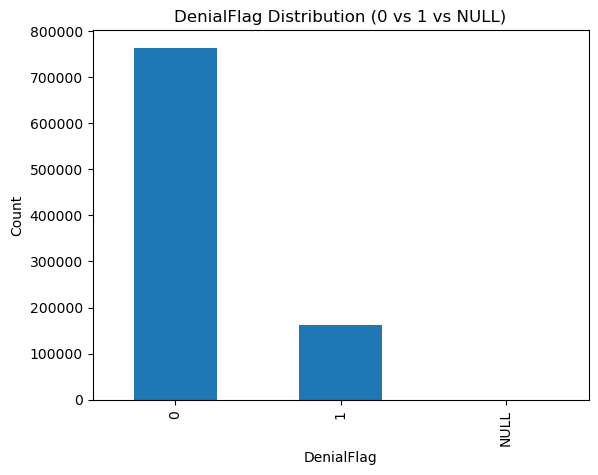

In [91]:
import matplotlib.pyplot as plt

# Create a new column with NULL label
df["DenialFlag_plot"] = df["DenialFlag"].map({0: "0", 1: "1"})
df["DenialFlag_plot"] = df["DenialFlag_plot"].fillna("NULL")

# Count values
counts = df["DenialFlag_plot"].value_counts().reindex(["0", "1", "NULL"])

# Plot
counts.plot(kind="bar")

plt.title("DenialFlag Distribution (0 vs 1 vs NULL)")
plt.xlabel("DenialFlag")
plt.ylabel("Count")

plt.show()

In [92]:
print(counts)

DenialFlag_plot
0       764553.0
1       161450.0
NULL         NaN
Name: count, dtype: float64


insight1:Since NULL is in target column, you must delete those rows:

In [93]:
#RECHECKING
print(df["DenialFlag"].isna().sum())  # should be 0

0


EDA 2-CHECKING IF THE CLASS IS IMABLANCED

In [94]:
print(df["DenialFlag"].value_counts(normalize=True))

DenialFlag
0.0    0.825649
1.0    0.174351
Name: proportion, dtype: float64


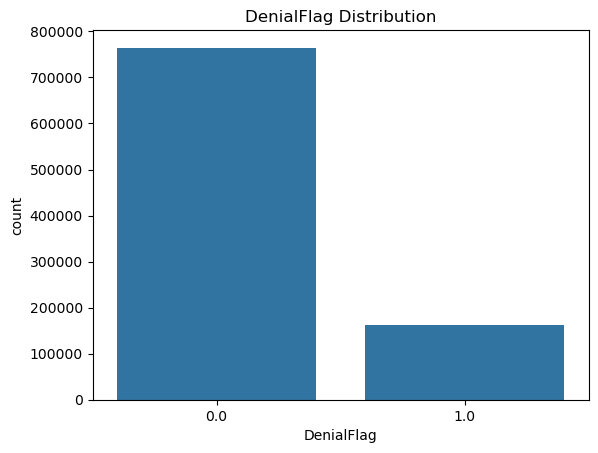

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["DenialFlag"])
plt.title("DenialFlag Distribution")
plt.show()

EDA 3 :SameDayCli = number of duplicate claims for same patient on same day ,to check duplicates
SameDayCli represents the count of repeated services for the same patient on the same day. Higher values indicate duplicate billing patterns

In [96]:
same_day = df.groupby("SameDayCli")["DenialFlag"].mean()
print(same_day)

SameDayCli
0    0.163408
1    0.624195
2    0.326733
3    0.425068
4    0.000000
5    0.300000
6    0.250000
7    0.000000
9    0.166667
Name: DenialFlag, dtype: float64


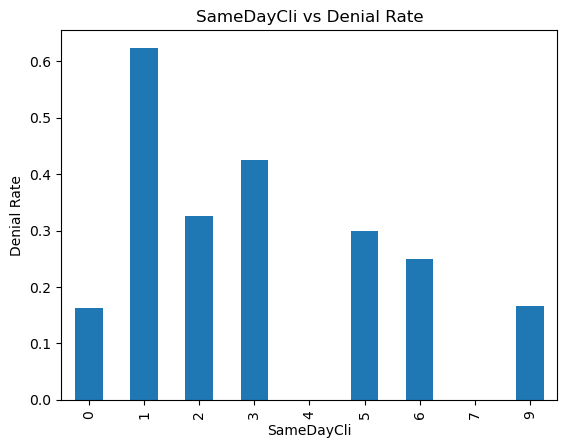

In [97]:
same_day.plot(kind="bar")
plt.title("SameDayCli vs Denial Rate")
plt.ylabel("Denial Rate")
plt.show()

INSIGHT:IT IS ABOUT DUPLICATION 
If a patient gets same treatment multiple times:

SameDayCli = 0 - normal (1 service)
SameDayCli = 1 - duplicate (2 services)
SameDayCli = 2 -more duplicates (3 services)
Insurance companies think:

More repeats = suspicious = higher denial chance

EDA 5 DELAY VS DENIAL------How many days it took to submit the claim after service

Delay = ClaimBillDate - ServiceDt
 Meaning of the two columns
 ServiceDt---Date when:Patient received treatment
 ClaimBillDate--Date when:Hospital sent bill to insurance

In [98]:
df.groupby("DenialFlag")["DaysBetServiceToBilling"].mean()

DenialFlag
0.0     6.830130
1.0    16.141604
Name: DaysBetServiceToBilling, dtype: float64

Denied claims take ~16 days  
Approved claims take ~7 days

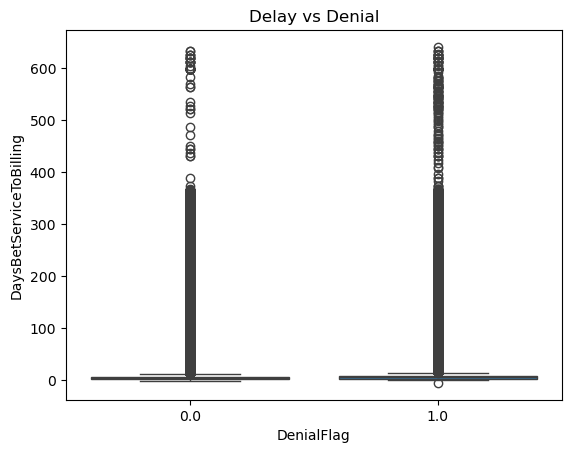

In [99]:

sns.boxplot(x="DenialFlag", y="DaysBetServiceToBilling", data=df)
plt.title("Delay vs Denial")
plt.show()

INSIGHT:HIGHER THE DELAY MORE THE CNACES OF DENIAL 

EDA6:sns.boxplot(x="DenialFlag", y="AmountCharged", data=df)
plt.show()

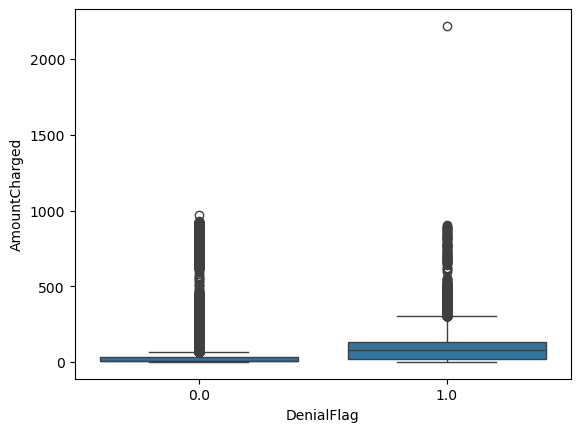

In [100]:
sns.boxplot(x="DenialFlag", y="AmountCharged", data=df)
plt.show()

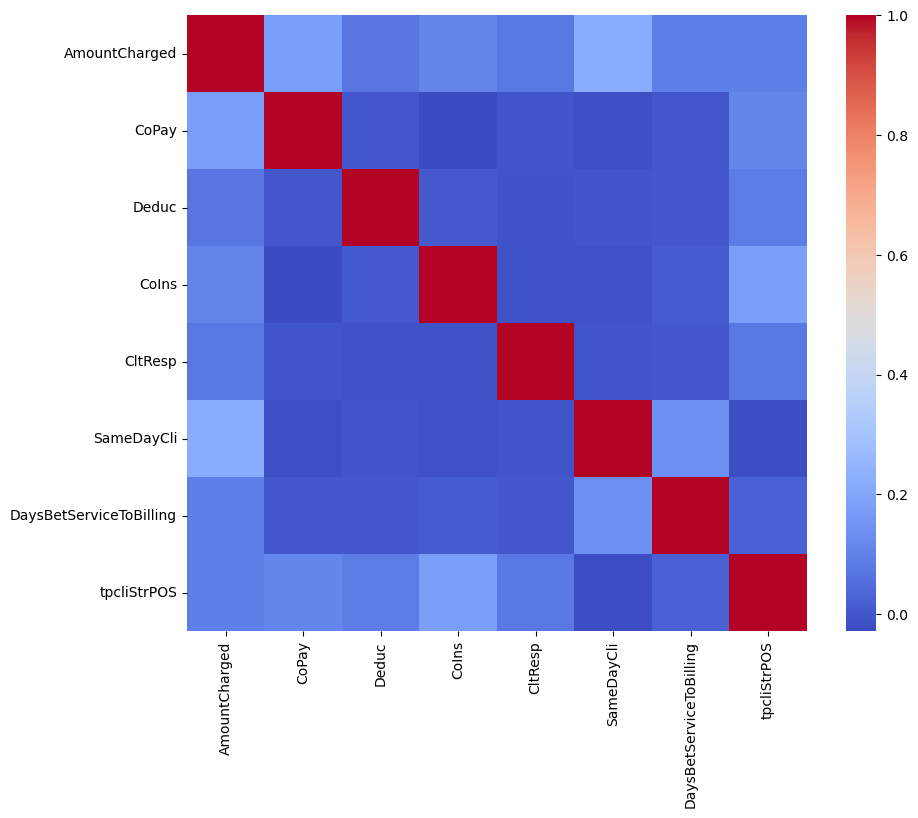

In [101]:
corr = X.corr(numeric_only=True)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

EDA8:PAYER VS DENINLA RATE :TELLS WHICH PAYER HAS HIGH DENIAL RATE

tells which insurnace company denies more

top riksy payers

In [102]:
payer_counts = df["Payer"].value_counts()

In [103]:
valid_payers = payer_counts[payer_counts > 1000].index

df_filtered = df[df["Payer"].isin(valid_payers)]

In [104]:
payer_denial = df_filtered.groupby("Payer")["DenialFlag"].mean().sort_values(ascending=False)

In [105]:


payer_stats = df_filtered.groupby("Payer")["DenialFlag"].agg(["mean", "count"])

payer_stats = payer_stats.sort_values(by="mean", ascending=False)

print(payer_stats.head(10))

                  mean  count
Payer                        
PAY_40056146  0.998190   1105
PAY_80544341  0.994627   5025
PAY_27002880  0.994382   1424
PAY_64304823  0.988889   1800
PAY_4772547   0.987689   2112
PAY_84374018  0.987410   1112
PAY_55650977  0.984449   1479
PAY_73462947  0.983929   6098
PAY_89522760  0.980976   1209
PAY_37327686  0.975610   2091


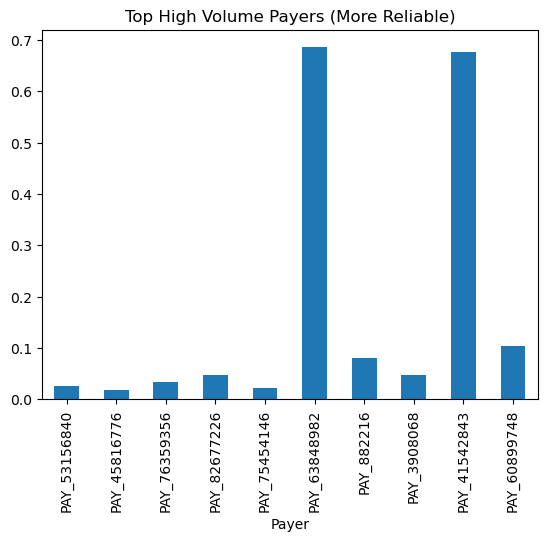

In [106]:
payer_stats.sort_values(by="count", ascending=False).head(10)["mean"].plot(kind="bar")
plt.title("Top High Volume Payers (More Reliable)")
plt.show()

CPT CODE VS DENIAL 
cpt code----What medical service was done

tells which service proceudre is denied more

In [107]:
# cpt_denial = df.groupby("CPTCode")["DenialFlag"].mean().sort_values(ascending=False)

# print(cpt_denial.head(10))


cpt_counts = df["CPTCode"].value_counts()

valid_cpt = cpt_counts[cpt_counts > 1000].index

df_cpt = df[df["CPTCode"].isin(valid_cpt)]

cpt_stats = df_cpt.groupby("CPTCode")["DenialFlag"].agg(["mean", "count"])

cpt_stats.sort_values(by="mean", ascending=False).head(10)

,mean,count
CPTCode,,
82075,0.751752,3424
G2074,0.717818,7481
G2078,0.710121,11629
G2077,0.690653,5670
G2087,0.690517,1761
99211,0.655721,1949
90837,0.623512,1344
90853,0.541887,2268
G2067,0.530546,38892


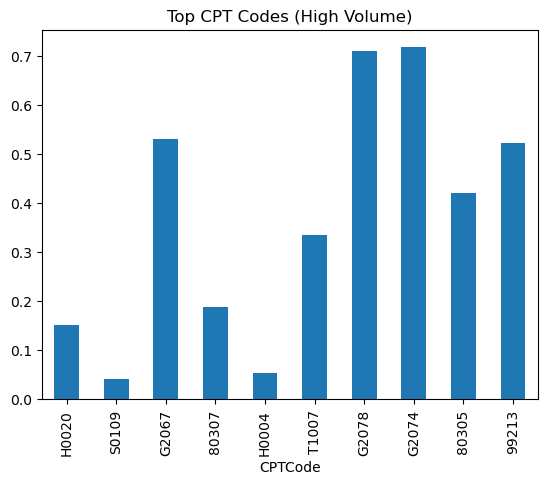

In [108]:
cpt_stats.sort_values(by="count", ascending=False).head(10)["mean"].plot(kind="bar")
plt.title("Top CPT Codes (High Volume)")
plt.show()

FEATURE ENGINEERING

In [109]:
df.isnull().sum().sort_values(ascending=False)

Clinic                     0
ServiceDt                  0
f21diag1                   0
tpcliStrPOS                0
tpcliStrModifier           0
DaysBetServiceToBilling    0
SameDayCli                 0
CltResp                    0
CoIns                      0
Deduc                      0
CoPay                      0
DenialFlag                 0
eligStatus                 0
ClaimFacilityNPI           0
BillingProviderNPI         0
Provider                   0
Payer                      0
ClaimBillDate              0
CPTCode                    0
AmountCharged              0
Service                    0
DenialFlag_plot            0
dtype: int64

In [110]:
print(df.columns.tolist())

['Clinic', 'ServiceDt', 'Service', 'AmountCharged', 'CPTCode', 'ClaimBillDate', 'Payer', 'Provider', 'BillingProviderNPI', 'ClaimFacilityNPI', 'eligStatus', 'DenialFlag', 'CoPay', 'Deduc', 'CoIns', 'CltResp', 'SameDayCli', 'DaysBetServiceToBilling', 'tpcliStrModifier', 'tpcliStrPOS', 'f21diag1', 'DenialFlag_plot']


In [111]:
print(df.columns)

Index(['Clinic', 'ServiceDt', 'Service', 'AmountCharged', 'CPTCode',
       'ClaimBillDate', 'Payer', 'Provider', 'BillingProviderNPI',
       'ClaimFacilityNPI', 'eligStatus', 'DenialFlag', 'CoPay', 'Deduc',
       'CoIns', 'CltResp', 'SameDayCli', 'DaysBetServiceToBilling',
       'tpcliStrModifier', 'tpcliStrPOS', 'f21diag1', 'DenialFlag_plot'],
      dtype='object')


In [112]:
df = df.drop(columns=["DenialFlag_plot"], errors="ignore")

In [113]:
df = df.drop(columns=["BillingProviderNPI","ClaimFacilityNPI"])

CONVERT DATES

In [114]:
df["ServiceDt"] = pd.to_datetime(df["ServiceDt"])
df["ClaimBillDate"] = pd.to_datetime(df["ClaimBillDate"])

FEATURE ENGINEERING

In [115]:
df["days_to_bill"] = (df["ClaimBillDate"] - df["ServiceDt"]).dt.days

In [116]:
df["service_day"] = df["ServiceDt"].dt.dayofweek

In [117]:
df["DenialFlag"] = df["DenialFlag"].astype(int)

In [118]:
print(df.columns)

Index(['Clinic', 'ServiceDt', 'Service', 'AmountCharged', 'CPTCode',
       'ClaimBillDate', 'Payer', 'Provider', 'eligStatus', 'DenialFlag',
       'CoPay', 'Deduc', 'CoIns', 'CltResp', 'SameDayCli',
       'DaysBetServiceToBilling', 'tpcliStrModifier', 'tpcliStrPOS',
       'f21diag1', 'days_to_bill', 'service_day'],
      dtype='object')


In [119]:
df = df.loc[:, ~df.columns.duplicated()]

In [120]:
print(df["DenialFlag"].dtype)
print(df["DenialFlag"].unique())

int64
[0 1]


In [121]:
payer_rate = df.groupby("Payer")["DenialFlag"].mean()
df["payer_denial_rate"] = df["Payer"].map(payer_rate)

In [122]:
cpt_rate = df.groupby("CPTCode")["DenialFlag"].mean()
df["cpt_denial_rate"] = df["CPTCode"].map(cpt_rate)

In [123]:
df.dtypes

Clinic                             object
ServiceDt                  datetime64[ns]
Service                            object
AmountCharged                     float64
CPTCode                            object
ClaimBillDate              datetime64[ns]
Payer                              object
Provider                           object
eligStatus                         object
DenialFlag                          int64
CoPay                             float64
Deduc                             float64
CoIns                             float64
CltResp                           float64
SameDayCli                          int64
DaysBetServiceToBilling             int64
tpcliStrModifier                   object
tpcliStrPOS                         int64
f21diag1                           object
days_to_bill                        int64
service_day                         int32
payer_denial_rate                 float64
cpt_denial_rate                   float64
dtype: object

In [124]:
df.isnull().sum().sum()

np.int64(0)

In [125]:
df_final=df.copy()

ENCODING PARY

In [126]:
X = df.drop(columns=["DenialFlag"])
y = df["DenialFlag"]

In [127]:
print(X.columns)

Index(['Clinic', 'ServiceDt', 'Service', 'AmountCharged', 'CPTCode',
       'ClaimBillDate', 'Payer', 'Provider', 'eligStatus', 'CoPay', 'Deduc',
       'CoIns', 'CltResp', 'SameDayCli', 'DaysBetServiceToBilling',
       'tpcliStrModifier', 'tpcliStrPOS', 'f21diag1', 'days_to_bill',
       'service_day', 'payer_denial_rate', 'cpt_denial_rate'],
      dtype='object')


In [128]:
df = df.sort_values("ClaimBillDate")

Time-Based Split  (BEST)

 Real-world scenario
 No leakage
 More reliable model
 Slight imbalance (handled separately)

 FINAL RECOMMENDATION
USE → Time-based split + class weighting

In [129]:
train_size = int(0.7 * len(df))
val_size = int(0.85 * len(df))

In [130]:
train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:val_size]
test_df = df.iloc[val_size:]

In [131]:
df["ClaimBillDate_copy"] = df["ClaimBillDate"]

dropping date columns after splitiing

In [ ]:
for d in [train_df, val_df, test_df]:
    d.drop(columns=["ServiceDt","ClaimBillDate"], inplace=True)

C:\Users\SreejaChiluveru\AppData\Local\Temp\ipykernel_20484\3495715443.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d.drop(columns=["ServiceDt","ClaimBillDate"], inplace=True)
C:\Users\SreejaChiluveru\AppData\Local\Temp\ipykernel_20484\3495715443.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d.drop(columns=["ServiceDt","ClaimBillDate"], inplace=True)
C:\Users\SreejaChiluveru\AppData\Local\Temp\ipykernel_20484\3495715443.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

In [133]:
train_df = train_df.drop(columns=["ServiceDt","ClaimBillDate"], errors="ignore")
val_df = val_df.drop(columns=["ServiceDt","ClaimBillDate"], errors="ignore")
test_df = test_df.drop(columns=["ServiceDt","ClaimBillDate"], errors="ignore")

In [134]:
cols_to_drop = ["ServiceDt","ClaimBillDate"]

train_df = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])

ENCODING

In [135]:
from sklearn.preprocessing import LabelEncoder

cat_cols = train_df.select_dtypes(include="object").columns

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    
    val_df[col] = val_df[col].map(mapping).fillna(-1)
    test_df[col] = test_df[col].map(mapping).fillna(-1)
    
    encoders[col] = le

creating X and Y

In [136]:
X_train = train_df.drop(columns=["DenialFlag"])
y_train = train_df["DenialFlag"]

X_val = val_df.drop(columns=["DenialFlag"])
y_val = val_df["DenialFlag"]

X_test = test_df.drop(columns=["DenialFlag"])
y_test = test_df["DenialFlag"]

HANDLING IMBALANCE

In [137]:
scale = (len(y_train) - y_train.sum()) / y_train.sum()

MODEL TRAINING

In [138]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [139]:
from sklearn.metrics import classification_report

train_pred = model.predict(X_train)

print("===== TRAIN REPORT =====")
print(classification_report(y_train, train_pred))

===== TRAIN REPORT =====
              precision    recall  f1-score   support

           0       0.98      0.94      0.96    540037
           1       0.76      0.91      0.83    108165

    accuracy                           0.94    648202
   macro avg       0.87      0.93      0.89    648202
weighted avg       0.94      0.94      0.94    648202



VALIDATE

In [140]:
print(X_val.dtypes)

Clinic                       int64
Service                    float64
AmountCharged              float64
CPTCode                      int64
Payer                      float64
Provider                   float64
eligStatus                   int64
CoPay                      float64
Deduc                      float64
CoIns                      float64
CltResp                    float64
SameDayCli                   int64
DaysBetServiceToBilling      int64
tpcliStrModifier             int64
tpcliStrPOS                  int64
f21diag1                     int64
days_to_bill                 int64
service_day                  int32
payer_denial_rate          float64
cpt_denial_rate            float64
dtype: object


In [141]:
X_val["Service"] = pd.to_numeric(X_val["Service"], errors="coerce")
X_test["Service"] = pd.to_numeric(X_test["Service"], errors="coerce")

In [142]:
X_val["Service"] = X_val["Service"].fillna(-1)
X_test["Service"] = X_test["Service"].fillna(-1)

In [143]:
X_train = X_train.apply(pd.to_numeric)
X_val = X_val.apply(pd.to_numeric)
X_test = X_test.apply(pd.to_numeric)

In [144]:
from sklearn.metrics import classification_report

val_pred = model.predict(X_val)
print(classification_report(y_val, val_pred))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94    113700
           1       0.70      0.91      0.79     25200

    accuracy                           0.91    138900
   macro avg       0.84      0.91      0.87    138900
weighted avg       0.93      0.91      0.92    138900



===================REPORT FOR VALIDATION:==================
              precision    recall  f1-score   support

           0       0.98      0.90      0.94    113700
           1       0.67      0.91      0.77     25200

    accuracy                           0.90    138900
   macro avg       0.83      0.91      0.86    138900
weighted avg       0.92      0.90      0.91    138900

===== TRAIN REPORT =====
              precision    recall  f1-score   support

           0       0.98      0.94      0.96    540037
           1       0.76      0.91      0.83    108165

    accuracy                           0.94    648202
   macro avg       0.87      0.93      0.89    648202
weighted avg       0.94      0.94      0.94    648202

HANDLE IMBALANCE

In [145]:
probs = model.predict_proba(X_val)[:,1]

for t in [0.2, 0.3, 0.4, 0.5,0.6,0.7]:
    preds = (probs > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_val, preds))


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      0.81      0.89    113700
           1       0.52      0.95      0.67     25200

    accuracy                           0.83    138900
   macro avg       0.75      0.88      0.78    138900
weighted avg       0.90      0.83      0.85    138900


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.98      0.85      0.91    113700
           1       0.59      0.93      0.72     25200

    accuracy                           0.87    138900
   macro avg       0.79      0.89      0.82    138900
weighted avg       0.91      0.87      0.88    138900


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.98      0.89      0.93    113700
           1       0.65      0.92      0.76     25200

    accuracy                           0.90    138900
   macro avg       0.82      0.90      0.85    138900
weighted avg       0.92   

In [146]:
test_probs = model.predict_proba(X_test)[:,1]
test_pred = (test_probs > 0.3).astype(int)

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.98      0.85      0.91    110816
           1       0.61      0.92      0.73     28085

    accuracy                           0.86    138901
   macro avg       0.79      0.88      0.82    138901
weighted avg       0.90      0.86      0.87    138901



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

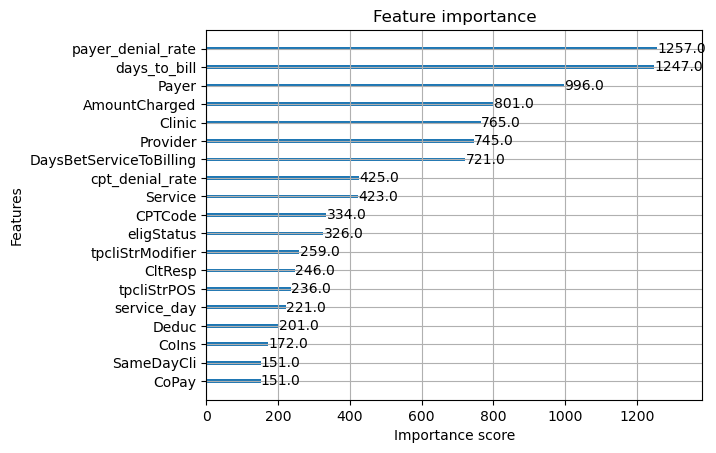

In [147]:
import xgboost as xgb
xgb.plot_importance(model)

TRYING OTHER SPLITTING TECHNIQUES-----------------

In [148]:
df_rand=df_final.copy()

In [152]:
cols_to_drop = ["ServiceDt", "ClaimBillDate"]

X_train_r = X_train_r.drop(columns=[c for c in cols_to_drop if c in X_train_r.columns])
X_val_r = X_val_r.drop(columns=[c for c in cols_to_drop if c in X_val_r.columns])
X_test_r = X_test_r.drop(columns=[c for c in cols_to_drop if c in X_test_r.columns])

In [153]:
print(X_train_r.columns)
print(X_val_r.columns)
print(X_test_r.columns)

Index(['Clinic', 'Service', 'AmountCharged', 'CPTCode', 'Payer', 'Provider',
       'eligStatus', 'CoPay', 'Deduc', 'CoIns', 'CltResp', 'SameDayCli',
       'DaysBetServiceToBilling', 'tpcliStrModifier', 'tpcliStrPOS',
       'f21diag1', 'days_to_bill', 'service_day', 'payer_denial_rate',
       'cpt_denial_rate'],
      dtype='object')
Index(['Clinic', 'Service', 'AmountCharged', 'CPTCode', 'Payer', 'Provider',
       'eligStatus', 'CoPay', 'Deduc', 'CoIns', 'CltResp', 'SameDayCli',
       'DaysBetServiceToBilling', 'tpcliStrModifier', 'tpcliStrPOS',
       'f21diag1', 'days_to_bill', 'service_day', 'payer_denial_rate',
       'cpt_denial_rate'],
      dtype='object')
Index(['Clinic', 'Service', 'AmountCharged', 'CPTCode', 'Payer', 'Provider',
       'eligStatus', 'CoPay', 'Deduc', 'CoIns', 'CltResp', 'SameDayCli',
       'DaysBetServiceToBilling', 'tpcliStrModifier', 'tpcliStrPOS',
       'f21diag1', 'days_to_bill', 'service_day', 'payer_denial_rate',
       'cpt_denial_rate'],
     

In [154]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X_train_r.select_dtypes(include="object").columns

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    
    X_train_r[col] = le.fit_transform(X_train_r[col].astype(str))
    
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    
    X_val_r[col] = X_val_r[col].map(mapping).fillna(-1)
    X_test_r[col] = X_test_r[col].map(mapping).fillna(-1)
    
    encoders[col] = le

In [156]:
X_train_r = X_train_r.apply(pd.to_numeric)
X_val_r = X_val_r.apply(pd.to_numeric)
X_test_r = X_test_r.apply(pd.to_numeric)

In [157]:
scale_r = (len(y_train_r) - y_train_r.sum()) / y_train_r.sum()

In [158]:
from xgboost import XGBClassifier

model_r = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_r,
    random_state=42
)

model_r.fit(X_train_r, y_train_r)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [159]:
from sklearn.metrics import classification_report

# Train
train_pred_r = model_r.predict(X_train_r)
print("=== RANDOM TRAIN ===")
print(classification_report(y_train_r, train_pred_r))

# Validation
val_pred_r = model_r.predict(X_val_r)
print("=== RANDOM VAL ===")
print(classification_report(y_val_r, val_pred_r))

# Test
test_pred_r = model_r.predict(X_test_r)
print("=== RANDOM TEST ===")
print(classification_report(y_test_r, test_pred_r))

=== RANDOM TRAIN ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.96    535187
           1       0.74      0.92      0.82    113015

    accuracy                           0.93    648202
   macro avg       0.86      0.93      0.89    648202
weighted avg       0.94      0.93      0.93    648202

=== RANDOM VAL ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.96    114683
           1       0.74      0.92      0.82     24217

    accuracy                           0.93    138900
   macro avg       0.86      0.92      0.89    138900
weighted avg       0.94      0.93      0.93    138900

=== RANDOM TEST ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.96    114683
           1       0.74      0.92      0.82     24218

    accuracy                           0.93    138901
   macro avg       0.86      0.92      0.89    138901
weighted avg  

outppputs of random split:
=== RANDOM TRAIN ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.96    535187
           1       0.74      0.92      0.82    113015

    accuracy                           0.93    648202
   macro avg       0.86      0.93      0.89    648202
weighted avg       0.94      0.93      0.93    648202

=== RANDOM VAL ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.96    114683
           1       0.74      0.92      0.82     24217

    accuracy                           0.93    138900
   macro avg       0.86      0.92      0.89    138900
weighted avg       0.94      0.93      0.93    138900

=== RANDOM TEST ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.96    114683
           1       0.74      0.92      0.82     24218
...
    accuracy                           0.93    138901
   macro avg       0.86      0.92      0.89    138901
weighted avg       0.94      0.93      0.93    138901

RANDOM FOREST===============================


In [161]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",   # important for imbalance
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [162]:

from sklearn.metrics import classification_report

print("=== RF TRAIN ===")
print(classification_report(y_train, rf.predict(X_train)))

print("=== RF VAL ===")
print(classification_report(y_val, rf.predict(X_val)))

print("=== RF TEST ===")
print(classification_report(y_test, rf.predict(X_test)))

=== RF TRAIN ===
              precision    recall  f1-score   support

           0       0.98      0.91      0.95    540037
           1       0.68      0.91      0.78    108165

    accuracy                           0.91    648202
   macro avg       0.83      0.91      0.86    648202
weighted avg       0.93      0.91      0.92    648202

=== RF VAL ===
              precision    recall  f1-score   support

           0       0.98      0.91      0.94    113700
           1       0.68      0.91      0.78     25200

    accuracy                           0.91    138900
   macro avg       0.83      0.91      0.86    138900
weighted avg       0.92      0.91      0.91    138900

=== RF TEST ===
              precision    recall  f1-score   support

           0       0.97      0.90      0.93    110816
           1       0.69      0.88      0.77     28085

    accuracy                           0.90    138901
   macro avg       0.83      0.89      0.85    138901
weighted avg       0.91   

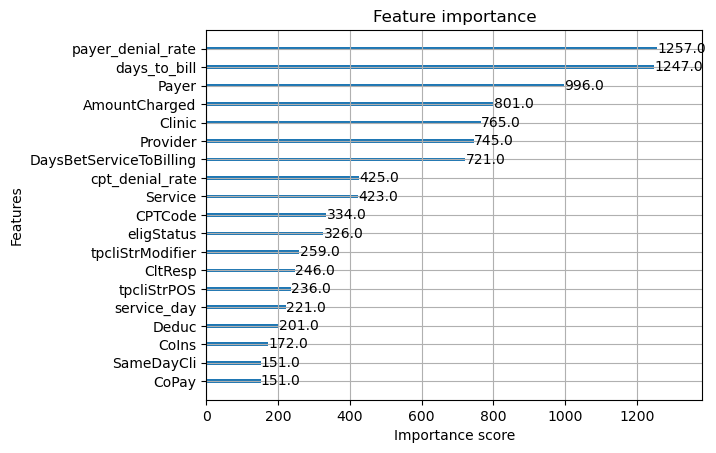

In [163]:
import xgboost as xgb
import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.show()

In [164]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred)
print(cm)


[[94232 16584]
 [ 2261 25824]]


LIGHTGBM MODEL

In [165]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [166]:
from lightgbm import LGBMClassifier

In [167]:
scale = (len(y_train) - y_train.sum()) / y_train.sum()

In [168]:
lgb = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    class_weight={0:1, 1:scale},   # VERY IMPORTANT
    random_state=42
)

In [169]:
lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 108165, number of negative: 540037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.121475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2474
[LightGBM] [Info] Number of data points in the train set: 648202, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,"{0: 1, 1: np.float64(4.992714833818703)}"
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [170]:
lgb_train_pred = lgb.predict(X_train)
lgb_val_pred = lgb.predict(X_val)
lgb_test_pred = lgb.predict(X_test)

In [171]:
from sklearn.metrics import classification_report

print("=== LGB TRAIN ===")
print(classification_report(y_train, lgb_train_pred))

print("=== LGB VAL ===")
print(classification_report(y_val, lgb_val_pred))

print("=== LGB TEST ===")
print(classification_report(y_test, lgb_test_pred))

=== LGB TRAIN ===
              precision    recall  f1-score   support

           0       0.98      0.94      0.96    540037
           1       0.74      0.91      0.82    108165

    accuracy                           0.93    648202
   macro avg       0.86      0.92      0.89    648202
weighted avg       0.94      0.93      0.93    648202

=== LGB VAL ===
              precision    recall  f1-score   support

           0       0.98      0.91      0.94    113700
           1       0.69      0.91      0.79     25200

    accuracy                           0.91    138900
   macro avg       0.84      0.91      0.86    138900
weighted avg       0.93      0.91      0.91    138900

=== LGB TEST ===
              precision    recall  f1-score   support

           0       0.97      0.90      0.93    110816
           1       0.69      0.89      0.78     28085

    accuracy                           0.90    138901
   macro avg       0.83      0.90      0.86    138901
weighted avg       0.91

MODEL COMPARISION:

Model	                 Recall	                                    Precision	                                        F1





RF                       	          0.88–0.91	             0.69	                       0.77




XGBoost	         0.91–0.92 	             0.61–0.70	                    0.79 



LightGBM	     0.89–0.91	             0.69 	                        0.78

THRESHOLD TUNING

In [173]:
probs = lgb.predict_proba(X_val)[:,1]

y_pred = (probs > 0.4).astype(int)

In [174]:
from sklearn.metrics import classification_report

print("Threshold = 0.4")
print(classification_report(y_val, y_pred))

Threshold = 0.4
              precision    recall  f1-score   support

           0       0.98      0.89      0.93    113700
           1       0.65      0.92      0.76     25200

    accuracy                           0.89    138900
   macro avg       0.81      0.90      0.84    138900
weighted avg       0.92      0.89      0.90    138900



DEFAULT THRESHOLD IS GOOD FOR LIGHT GBM